In [14]:
print("Hola, notebook funcionando")

Hola, notebook funcionando


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

print("pandas:", pd.__version__)
print("duckdb:", duckdb.__version__)

pandas: 2.3.3
duckdb: 1.5.1


In [16]:
data = {
    "categoria": ["Incidente", "Incidente", "Cambio", "Problema", "Incidente"],
    "prioridad": ["Alta", "Media", "Alta", "Baja", "Alta"],
    "tiempo_resolucion_horas": [4, 8, 2, 24, 6]
}

df = pd.DataFrame(data)
df

,categoria,prioridad,tiempo_resolucion_horas
0,Incidente,Alta,4
1,Incidente,Media,8
2,Cambio,Alta,2
3,Problema,Baja,24
4,Incidente,Alta,6


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   categoria                5 non-null      object
 1   prioridad                5 non-null      object
 2   tiempo_resolucion_horas  5 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 252.0+ bytes


In [18]:
df.describe(include="all")

,categoria,prioridad,tiempo_resolucion_horas
count,5,5,5.000000
unique,3,3,NaN
top,Incidente,Alta,NaN
freq,3,3,NaN
mean,NaN,NaN,8.800000
std,NaN,NaN,8.786353
min,NaN,NaN,2.000000
25%,NaN,NaN,4.000000
50%,NaN,NaN,6.000000
75%,NaN,NaN,8.000000


In [19]:
df["categoria"].value_counts()

categoria
Incidente    3
Cambio       1
Problema     1
Name: count, dtype: int64

In [20]:
df.groupby("prioridad")["tiempo_resolucion_horas"].mean()

prioridad
Alta      4.0
Baja     24.0
Media     8.0
Name: tiempo_resolucion_horas, dtype: float64

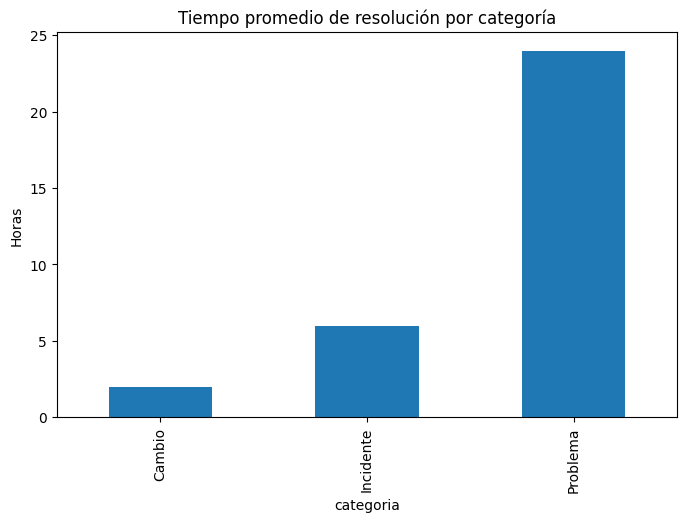

In [21]:
df.groupby("categoria")["tiempo_resolucion_horas"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Tiempo promedio de resolución por categoría")
plt.ylabel("Horas")
plt.show()









In [24]:
import pandas as pd

df = pd.read_csv("../data/raw/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
df.shape

(891, 12)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [27]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [28]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

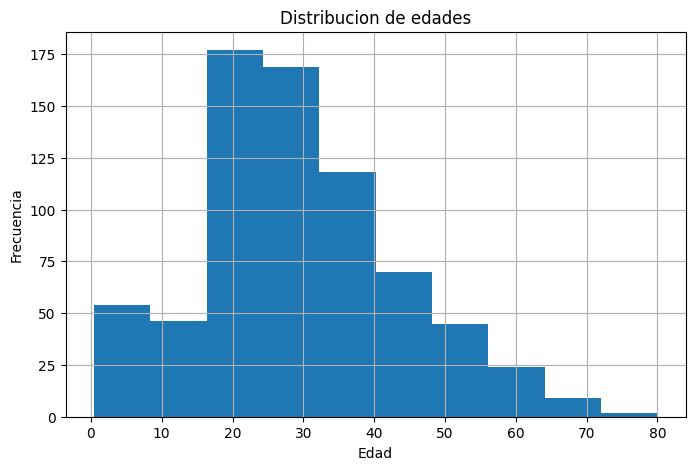

In [30]:
import matplotlib.pyplot as plt

df["Age"].hist(figsize=(8,5))
plt.title("Distribucion de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

In [31]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [33]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [34]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [35]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [36]:
df["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [37]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [39]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [40]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

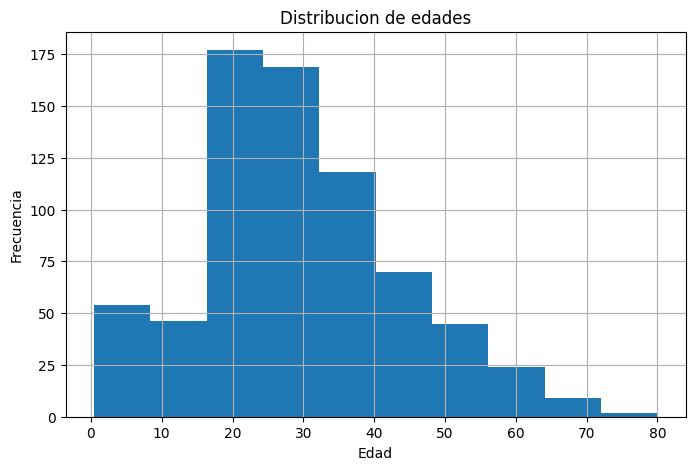

In [41]:
import matplotlib.pyplot as plt

df["Age"].hist(figsize=(8,5))
plt.title("Distribucion de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

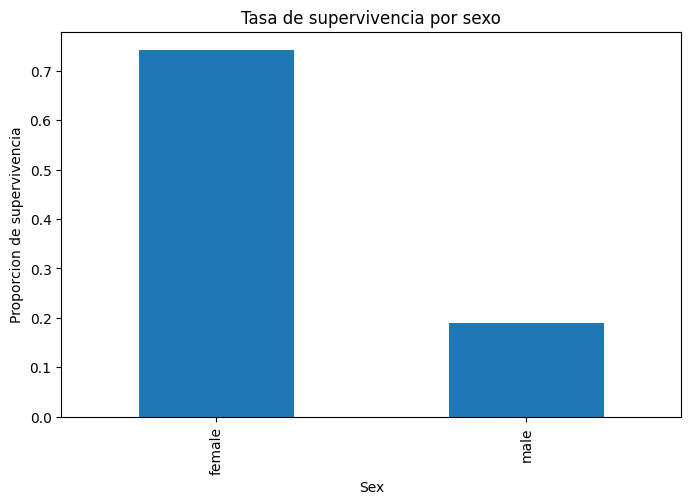

In [42]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Tasa de supervivencia por sexo")
plt.ylabel("Proporcion de supervivencia")
plt.show()

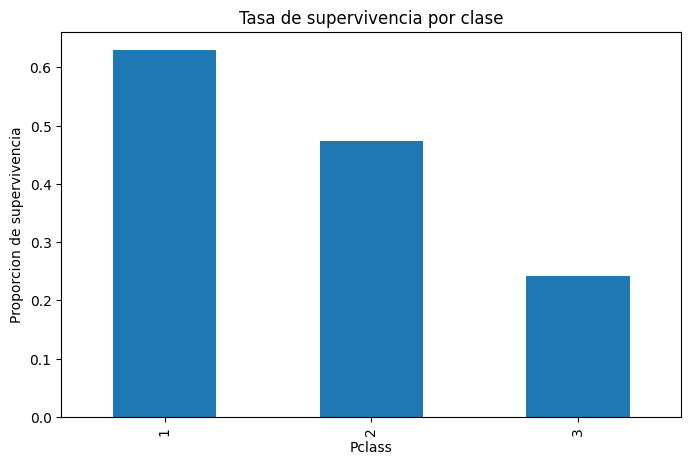

In [43]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Tasa de supervivencia por clase")
plt.ylabel("Proporcion de supervivencia")
plt.show()

## Hallazgos iniciales

- El dataset contiene 891 registros y 12 columnas.
- La columna `Age` tiene valores faltantes relevantes y requerirá tratamiento.
- La columna `Cabin` tiene demasiados nulos para ser útil en un análisis inicial simple.
- La supervivencia parece variar según sexo y clase del pasajero.

In [47]:
df.groupby("Sex")["Survived"].mean()
df.groupby("Pclass")["Survived"].mean()
df["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Vamos a limpiar los datos ahora

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df_clean = df.copy()
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [50]:
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [51]:
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

In [52]:
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

In [53]:
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [54]:
print("Nulos en Age antes:", df["Age"].isnull().sum())
print("Nulos en Age después:", df_clean["Age"].isnull().sum())
print("Mediana usada:", df["Age"].median())

Nulos en Age antes: 177
Nulos en Age después: 0
Mediana usada: 28.0


In [55]:
(df_clean["Cabin"].isnull().sum() / len(df_clean)) * 100

np.float64(77.10437710437711)

In [56]:
df_model = df_clean.drop(columns=["Cabin"])
df_model.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [57]:
df_model.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Limpieza inicial

- Se creó una copia del dataset original para trabajar sin alterar la fuente.
- Los valores faltantes de `Age` se imputaron con la mediana.
- Los valores faltantes de `Embarked` se imputaron con la moda.
- La columna `Cabin` se excluyó del análisis inicial por su alto porcentaje de valores faltantes.